ty	0.0184

In [5]:
import sys
import sys
sys.path.append(r"C:\Users\Rakesh\Documents\summer-project\src")

from two_level_mc import * # adjust if your notebook is nested differently
from functions_v2 import *

In [7]:
with open(r"../../data/raw/facebook_combined.txt") as f:
    for i, line in enumerate(f):
        if i < 5:
            print(repr(line))

'0 1\n'
'0 2\n'
'0 3\n'
'0 4\n'
'0 5\n'


In [9]:
edges, n_vertices, edge_weights = load_graph(r"../../data/raw/facebook_combined.txt")
print(f"n_vertices={n_vertices}, edges={len(edges)}")

✓ Loaded: ../../data/raw/facebook_combined.txt
  Vertices : 4039
  Edges    : 88234
  Weighted : no

n_vertices=4039, edges=88234


In [11]:
G_nx = nx.Graph()
G_nx.add_edges_from(edges)
num_components = check_connectivity(edges, n_vertices)
if num_components > 1:
    edges, n_vertices, edge_weights = filter_to_largest_component(edges, n_vertices, edge_weights)
    G_nx = nx.Graph()
    G_nx.add_edges_from(edges)

Components: 1
  -> Graph is fully connected, safe to proceed



In [13]:
# phase 1 and 2
A, D, L = build_graph_matrices(edges, n_vertices)
lambda_min = compute_lambda_min(L, D)
L_sigma = build_shifted_laplacian(L, D, lambda_min)
print(f"lambda_min: {lambda_min}")
print(f"L_sigma type: {type(L_sigma)}")

✓ Phase 1 complete: A, D, L built as sparse matrices
  Matrix size : 4039 x 4039
  Degree range: [1, 1045]
  Non-zeros in L: 180507

✓ lambda_min = 0.000837
  (eigenvalues found: [0.         0.00083651])
✓ Phase 2 complete: L_sigma built (sigma^2 = 0.25)
  L_sigma type: sparse

lambda_min: 0.0008365064567879165
L_sigma type: <class 'scipy.sparse._csc.csc_matrix'>


Computing layout...


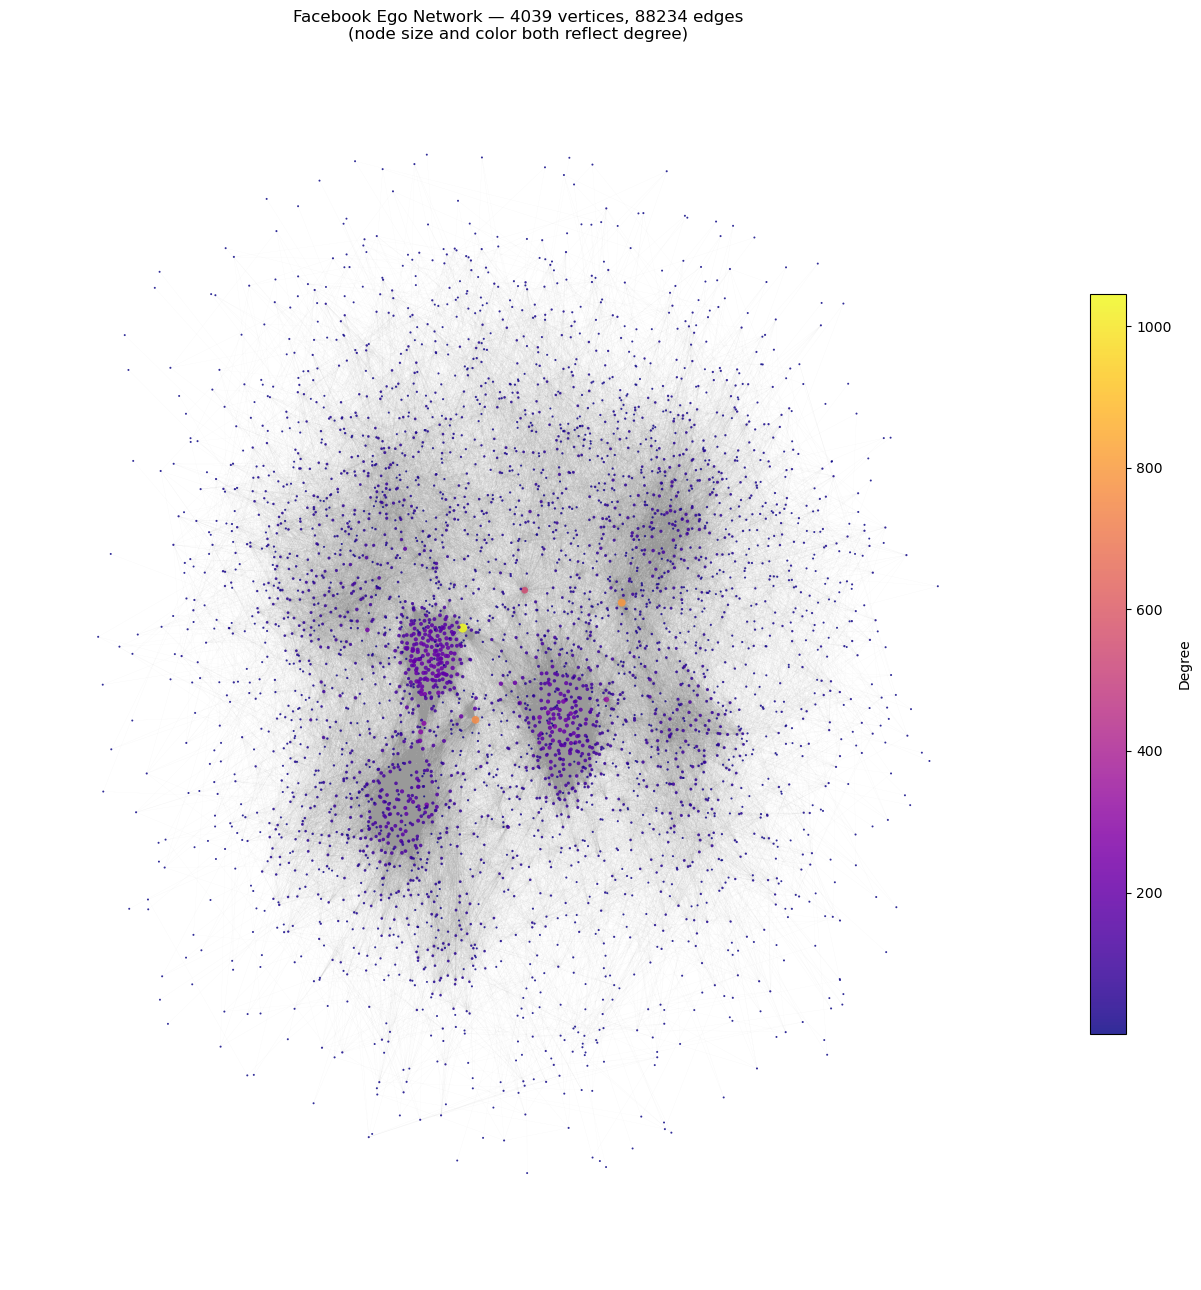

In [33]:
import matplotlib.pyplot as plt
import numpy as np

degrees = dict(G_nx.degree())
deg_values = np.array([degrees[n] for n in G_nx.nodes()])

print("Computing layout...")
pos = nx.spring_layout(G_nx, seed=7, k=0.1, iterations=15)

fig, ax = plt.subplots(figsize=(13, 13), facecolor='white')

nx.draw_networkx_edges(G_nx, pos, ax=ax, width=0.1, edge_color='#999999', alpha=0.15)

# KEY FIX: scale node size to a small, fixed range (2-42), not raw degree values
node_sizes = 2 + (deg_values / deg_values.max()) * 40

nodes = nx.draw_networkx_nodes(
    G_nx, pos, ax=ax,
    node_size=node_sizes,
    node_color=deg_values,
    cmap='plasma',
    edgecolors='none',
    alpha=0.85
)

plt.colorbar(nodes, ax=ax, label='Degree', shrink=0.6)
ax.set_title(f"Facebook Ego Network — {G_nx.number_of_nodes()} vertices, {G_nx.number_of_edges()} edges\n"
             f"(node size and color both reflect degree)")
ax.axis('off')
plt.tight_layout()
plt.savefig('facebook_actual.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

In [18]:
from networkx.algorithms.community import greedy_modularity_communities, modularity

communities = list(greedy_modularity_communities(G_nx))
communities_sorted = sorted(communities, key=len, reverse=True)

print(f"Found {len(communities_sorted)} communities")
print(f"Sizes (top 10): {[len(c) for c in communities_sorted[:10]]}")

mod_score = modularity(G_nx, communities_sorted)
print(f"Modularity: {mod_score:.4f}")

Found 13 communities
Sizes (top 10): [983, 815, 548, 543, 372, 219, 208, 206, 59, 37]
Modularity: 0.7774


In [20]:
gamma_in = list(communities_sorted[0])   # 983 vertices
gamma_out = list(communities_sorted[1])  # 815 vertices

boundary_fraction = check_boundary_fraction(gamma_in, gamma_out, n_vertices)

gamma_in: 983, gamma_out: 815, n_vertices: 4039
Boundary fraction: 44.5160%
  -> HIGH RISK. Comparable to or worse than confirmed failures (Rhesus 25%, bio-CE-GN 70%). Consider a different gamma-selection method, or (for diameter-endpoint selection) a smaller k_hop relative to the graph's diameter, before proceeding.


In [22]:
def top_degree_subset(community, G_nx, fraction=0.05):
    community_list = list(community)
    degrees = [(v, G_nx.degree(v)) for v in community_list]
    degrees_sorted = sorted(degrees, key=lambda x: x[1], reverse=True)
    n_keep = max(1, int(len(community_list) * fraction))
    return [v for v, d in degrees_sorted[:n_keep]]

gamma_in = top_degree_subset(communities_sorted[0], G_nx, fraction=0.05)
gamma_out = top_degree_subset(communities_sorted[1], G_nx, fraction=0.05)

boundary_fraction = check_boundary_fraction(gamma_in, gamma_out, n_vertices)

gamma_in: 49, gamma_out: 40, n_vertices: 4039
Boundary fraction: 2.2035%
  -> Untested range -- proceed but verify interior_coarse is non-empty and substantial after aggregation.


In [24]:
aggregate_of, n_coarse = build_capped_aggregation(G_nx, gamma_in, gamma_out, max_size=10)
summary = summarize_aggregation(aggregate_of, n_coarse, gamma_in, gamma_out)

n_coarse: 1967 (1967 aggregates)
Size distribution -- min: 1, max: 10, mean: 2.05
Singletons: 13 (0.7%)
gamma_in_coarse: 49, gamma_out_coarse: 40
Overlap (must be empty): set()
Interior coarse vertices: 1878 (95.5%)


In [26]:
setup = TwoLevelSetup.build(
    edges, n_vertices, L_sigma, lambda_min,
    gamma_in, gamma_out,
    build_incidence_matrix, sparse_cholesky,
    max_size=10
)

gamma_in: 49, gamma_out: 40, n_vertices: 4039
Boundary fraction: 2.2035%
  -> Untested range -- proceed but verify interior_coarse is non-empty and substantial after aggregation.
n_coarse: 1967 (1967 aggregates)
Size distribution -- min: 1, max: 10, mean: 2.05
Singletons: 13 (0.7%)
gamma_in_coarse: 49, gamma_out_coarse: 40
Overlap (must be empty): set()
Interior coarse vertices: 1878 (95.5%)
coarse edges: 48683 (from 88234 fine edges)


In [46]:
import time
t0 = time.time()
qf, qc = run_one_paired_sample(setup, seed=0)
print(f"Single sample: {time.time()-t0:.2f}s, Q_fine={qf:.4f}, Q_coarse={qc:.4f}")

Single sample: 3.04s, Q_fine=714.1967, Q_coarse=893.2317


In [48]:
result_small = run_paired_validation(setup, N=100)

Paired samples: 100%|██████████| 100/100 [01:12<00:00,  1.37sample/s, Q_fine=714.8817, Q_coarse=894.0114]


N = 100 paired samples
Q_fine   : mean=714.881690  var=1.297304
Q_coarse : mean=894.011427  var=2.003893
Q_fine - Q_coarse : mean=-179.129737  var=0.091331
Correlation(Q_fine, Q_coarse): 0.9954
Variance reduction: 14.20x


Paired samples: 100%|██████████| 500/500 [05:13<00:00,  1.59sample/s, Q_fine=714.7947, Q_coarse=893.9098]



N = 500 paired samples
Q_fine   : mean=714.794651  var=1.230638
Q_coarse : mean=893.909846  var=1.955974
Q_fine - Q_coarse : mean=-179.115195  var=0.097215
Correlation(Q_fine, Q_coarse): 0.9956
Variance reduction: 12.66x


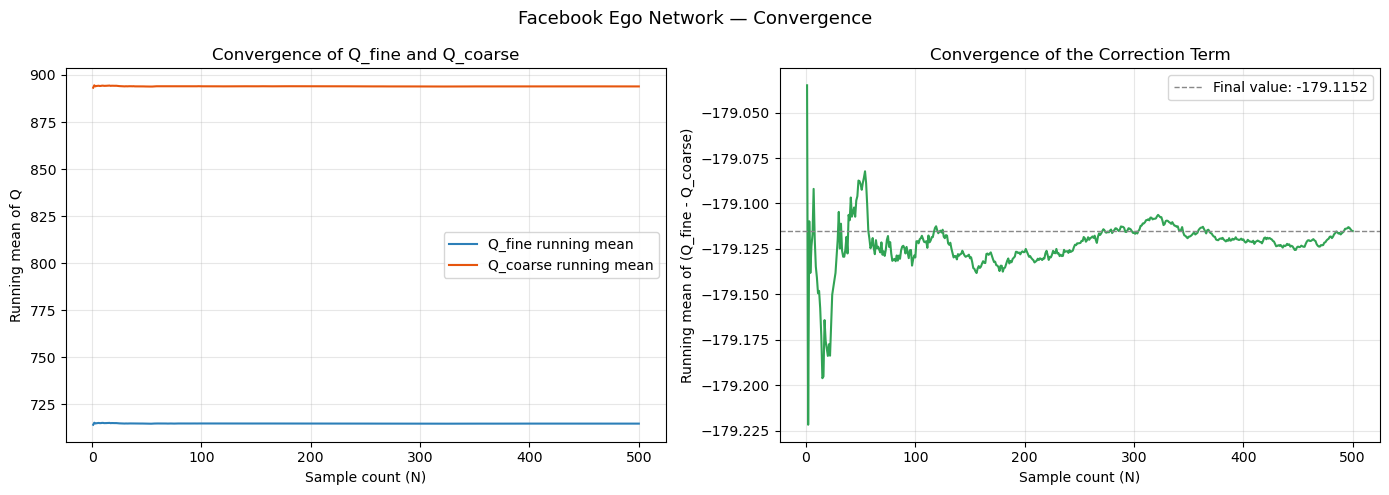

In [50]:
result = run_paired_validation(setup, N=500)
plot_convergence(result, title="Facebook Ego Network — Convergence")

Computing layout...


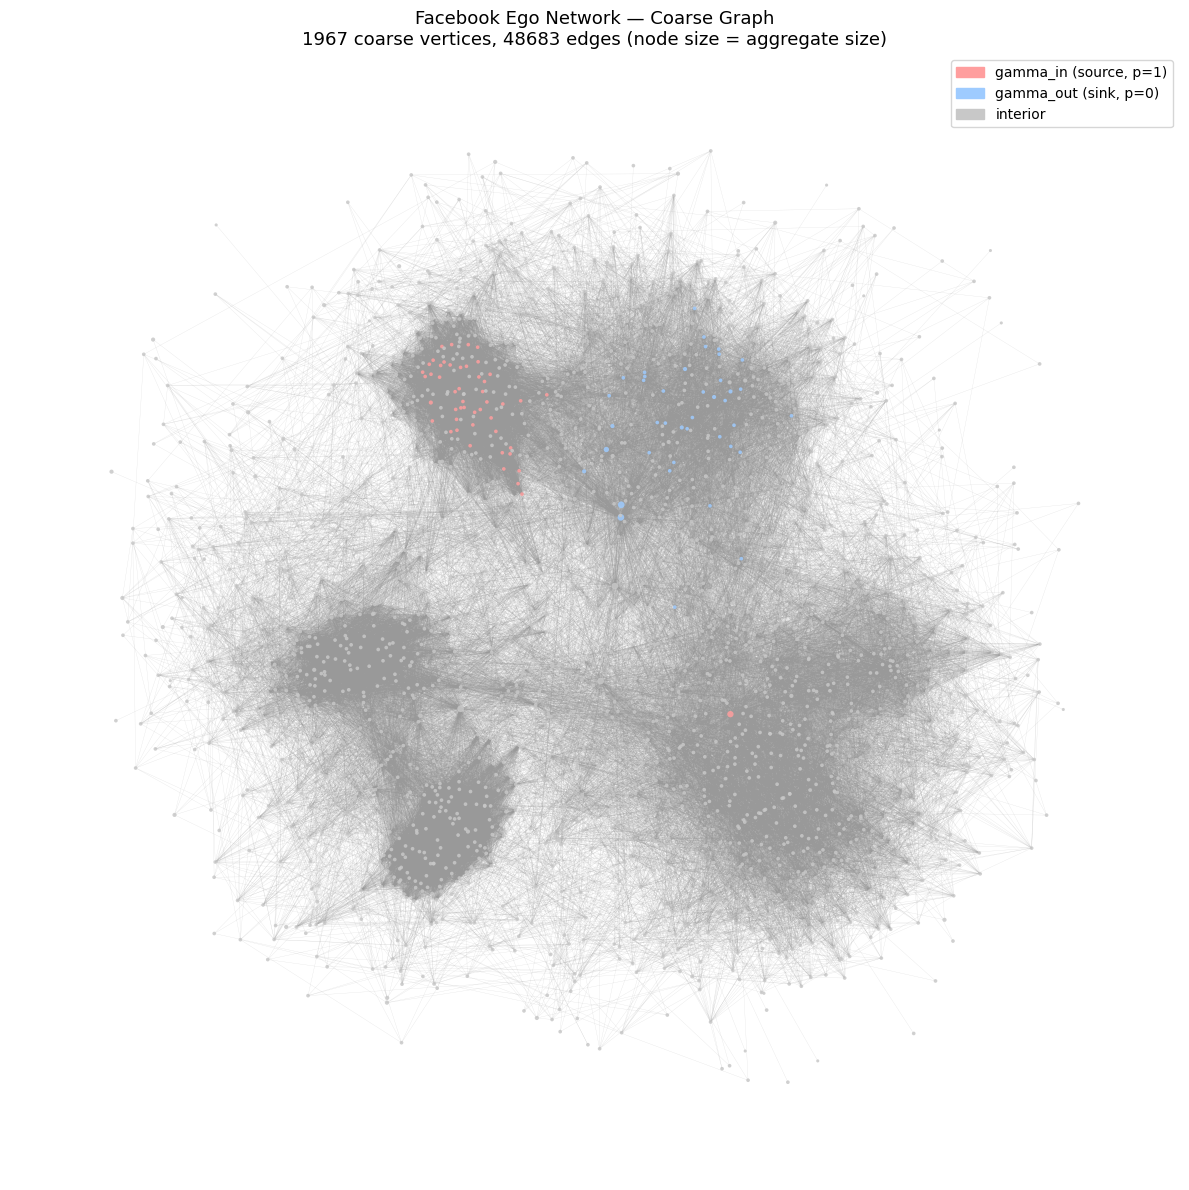

In [28]:
def visualize_coarse_graph(setup, aggregate_of, title="Coarse Graph"):
    G_coarse = nx.Graph()
    G_coarse.add_nodes_from(range(setup.n_coarse))
    G_coarse.add_edges_from(setup.coarse_edges)

    groups = {}
    for v, a in aggregate_of.items():
        groups.setdefault(a, []).append(v)
    sizes = {a: len(m) for a, m in groups.items()}
    node_sizes = [3 + sizes.get(a, 1) * 2 for a in G_coarse.nodes()]

    gamma_in_coarse_set = set(setup.gamma_in_coarse)
    gamma_out_coarse_set = set(setup.gamma_out_coarse)
    node_colors = []
    for a in G_coarse.nodes():
        if a in gamma_in_coarse_set:
            node_colors.append('#ff9e9e')   # source
        elif a in gamma_out_coarse_set:
            node_colors.append('#9ecbff')   # sink
        else:
            node_colors.append('#c8c8c8')   # interior

    fig, ax = plt.subplots(figsize=(12, 12), facecolor='white')
    print("Computing layout...")
    pos = nx.spring_layout(G_coarse, seed=7, k=0.2, iterations=20)

    nx.draw_networkx_edges(G_coarse, pos, ax=ax, width=0.2, edge_color='#999', alpha=0.3)
    nx.draw_networkx_nodes(G_coarse, pos, ax=ax, node_size=node_sizes,
                            node_color=node_colors, edgecolors='none', alpha=0.85)

    legend_patches = [
        mpatches.Patch(color='#ff9e9e', label='gamma_in (source, p=1)'),
        mpatches.Patch(color='#9ecbff', label='gamma_out (sink, p=0)'),
        mpatches.Patch(color='#c8c8c8', label='interior'),
    ]
    ax.legend(handles=legend_patches, loc='upper right', fontsize=10)

    ax.set_title(f"{title}\n{setup.n_coarse} coarse vertices, {len(setup.coarse_edges)} edges "
                 f"(node size = aggregate size)", fontsize=13)
    ax.axis('off')
    plt.tight_layout()
    plt.savefig('facebook_coarse.png', dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()

visualize_coarse_graph(setup, aggregate_of, title="Facebook Ego Network — Coarse Graph")